# Projet End-to-End : Détection de Fraude à l'Assurance Auto
**Auteur :** Ilyes Haddane  
**Objectif :** Explorer un jeu de données de sinistres automobiles pour identifier les comportements suspects et les patterns de fraude, avant d'appliquer des modèles d'Intelligence Artificielle (Machine Learning).

---
## 1. Importation et Nettoyage initial des données
Dans cette première étape, nous chargeons les librairies analytiques et nettoyons les anomalies évidentes (comme les conducteurs ayant un âge saisi à 0).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style pour avoir des graphiques propres et modernes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Charger les données (attention au chemin, on recule d'un dossier avec '..')
df = pd.read_csv('../data/carclaims.csv')

# 2. Nettoyage rapide : Enlever les conducteurs d'âge 0 (une erreur classique dans ce dataset)
df = df[df['Age'] > 0]

print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
df.head(3)

Le dataset contient 15100 lignes et 33 colonnes.


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No


---
## 2. Analyse Exploratoire (EDA)
### A. Le jeu de données est-il déséquilibré ?
En détection de fraude, le problème numéro 1 est le déséquilibre des classes : il y a toujours beaucoup plus de dossiers honnêtes que de fraudeurs. Vérifions la proportion exacte dans notre base de données.

/var/folders/83/vzd01t1d1yl2mfpjlysjlmmc0000gn/T/ipykernel_76479/2622893812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='FraudFound', palette=['#2ecc71', '#e74c3c'])


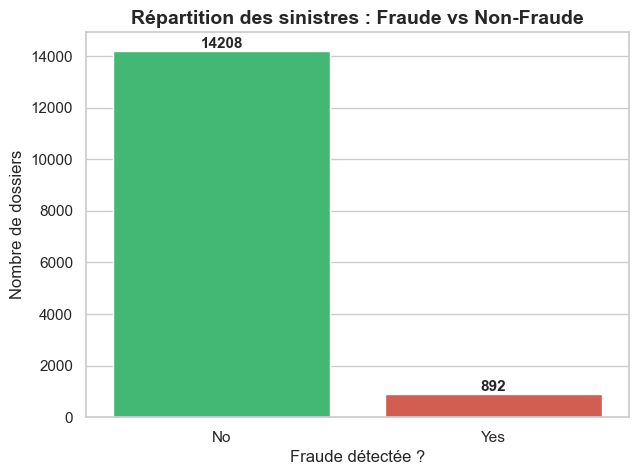

In [3]:
# Configuration de la taille du graphique
plt.figure(figsize=(7, 5))

# Création du graphique en barres avec Seaborn
ax = sns.countplot(data=df, x='FraudFound', palette=['#2ecc71', '#e74c3c'])

# Personnalisation (Titres et Axes)
plt.title('Répartition des sinistres : Fraude vs Non-Fraude', fontsize=14, fontweight='bold')
plt.xlabel('Fraude détectée ?', fontsize=12)
plt.ylabel('Nombre de dossiers', fontsize=12)

# Boucle pour ajouter le chiffre exact au-dessus de chaque barre
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

### B. Quels types de véhicules sont les plus impliqués dans les fraudes ?
Maintenant que nous savons que la fraude est un événement rare dans notre base, cherchons des "patterns". Est-ce qu'une catégorie de véhicule en particulier (Sport, Berline...) attire plus de fausses déclarations ?

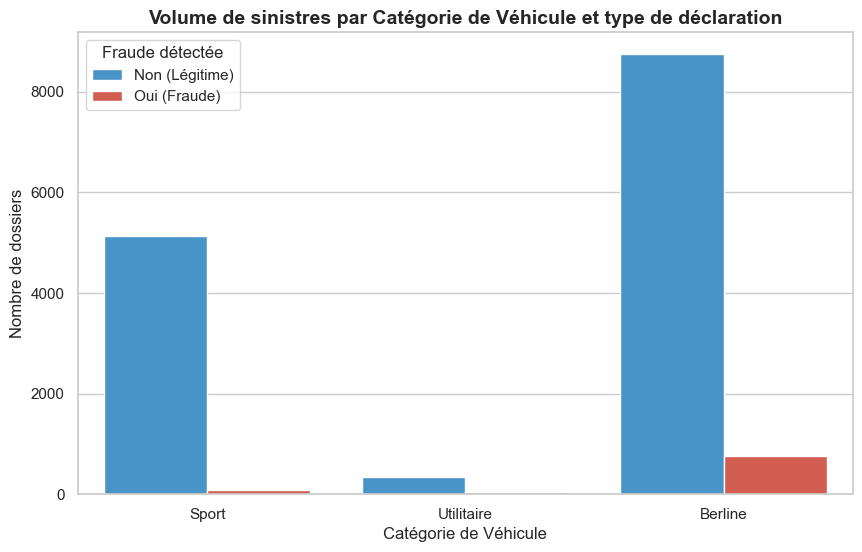

In [4]:
# 1. On crée un petit dictionnaire de traduction
traduction_vehicules = {
    'Sport': 'Sport',
    'Utility': 'Utilitaire',
    'Sedan': 'Berline'
}

# 2. On remplace les valeurs anglaises par les françaises dans notre DataFrame
df['VehicleCategory'] = df['VehicleCategory'].replace(traduction_vehicules)

# 3. Le code de ton graphique (inchangé, mais il va prendre les nouveaux noms !)
plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df, x='VehicleCategory', hue='FraudFound', palette=['#3498db', '#e74c3c'])

plt.title('Volume de sinistres par Catégorie de Véhicule et type de déclaration', fontsize=14, fontweight='bold')
plt.xlabel('Catégorie de Véhicule', fontsize=12)
plt.ylabel('Nombre de dossiers', fontsize=12)
plt.legend(title='Fraude détectée', labels=['Non (Légitime)', 'Oui (Fraude)'])

plt.show()

---
## 3. Analyse Multivariée : Matrice de Corrélation
Avant de passer à la modélisation (Machine Learning), nous devons vérifier quelles variables numériques sont mathématiquement liées entre elles, et surtout, lesquelles sont corrélées avec notre variable cible (`FraudFound`). 

*Note : Pour que la corrélation fonctionne, nous transformons temporairement notre cible "Yes/No" en "1/0".*

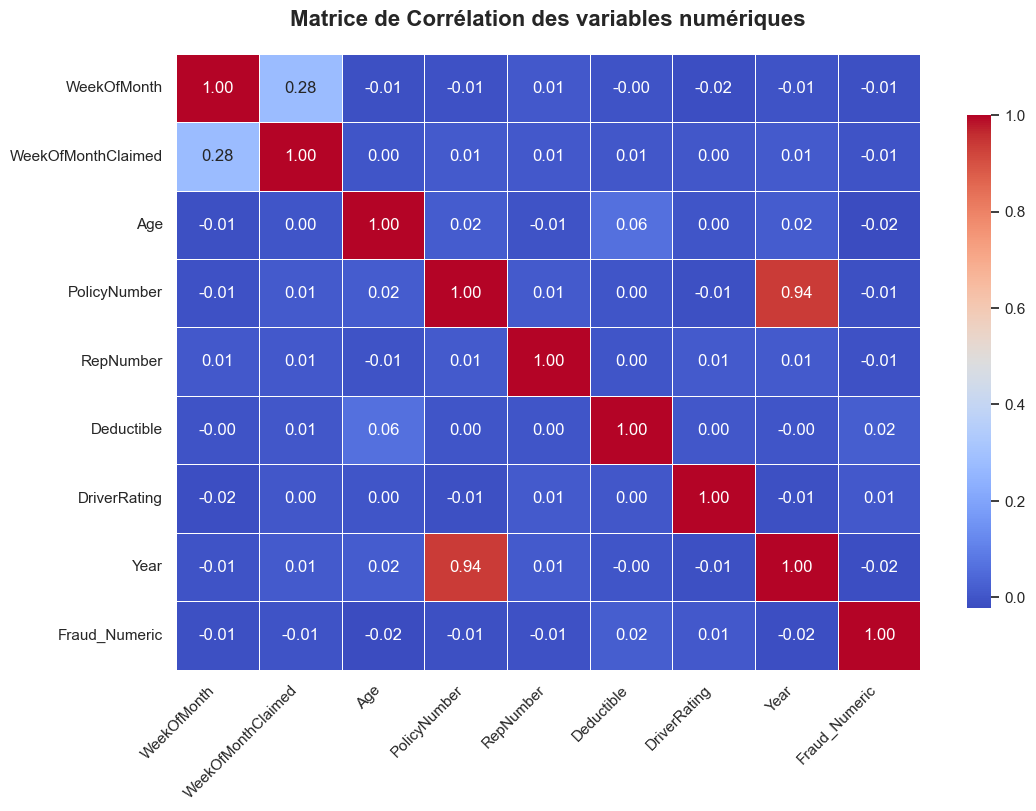

In [5]:
# 1. On crée une version numérique de notre cible (1 = Fraude, 0 = Non Fraude)
df['Fraud_Numeric'] = df['FraudFound'].map({'Yes': 1, 'No': 0})

# 2. On isole uniquement les colonnes numériques pour éviter les erreurs de calcul
colonnes_numeriques = df.select_dtypes(include=['int64', 'float64'])

# 3. On calcule la matrice de corrélation de Pearson
matrice_corr = colonnes_numeriques.corr()

# 4. On dessine la Heatmap avec Seaborn
plt.figure(figsize=(12, 8))

# annot=True affiche les chiffres, cmap change les couleurs, fmt=".2f" garde 2 chiffres après la virgule
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Matrice de Corrélation des variables numériques', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # On incline les labels pour que ce soit lisible
plt.show()

> **Conclusion de l'EDA :**
> - La matrice de corrélation nous montre si certaines variables (comme l'âge du conducteur ou la franchise 'Deductible') ont un impact linéaire direct sur la probabilité de fraude.
> - Dans la détection de fraude, les corrélations linéaires sont souvent très faibles (proches de 0), car les fraudeurs essaient de se fondre dans la masse. 
> - **Prochaine étape :** C'est exactement pour cette raison que nous aurons besoin d'algorithmes de Machine Learning non-linéaires (comme les Random Forests) pour détecter des patterns complexes inaudibles à l'œil nu !